# Notebook 03: Model Training

**Project:** Deep Learning-Based Pneumonia Classification from Chest Radiographs with Grad-CAM Interpretability  
**Author:** Viet Thang Tran | L00196203 | Atlantic Technological University

---

## Purpose

This notebook trains three pretrained CNN architectures on the preprocessed chest X-ray
dataset using transfer learning and differential learning rates.

## Models Trained

| Model | Pretrained On | Unfrozen Layers | Trainable Params |
|---|---|---|---|
| ResNet-50 | ImageNet (V2) | layer3, layer4, fc | ~22M |
| DenseNet-121 | ImageNet (V1) | denseblock3 onwards, classifier | ~5.5M |
| EfficientNet-B0 | ImageNet (V1) | features[5-8], classifier | ~3.7M |

## Training Configuration

| Setting | Value |
|---|---|
| Optimiser | AdamW (weight decay = 1e-4) |
| Loss | BCEWithLogitsLoss with class weights |
| Convolutional LR | 1e-4 |
| Classifier LR | 1e-3 |
| Scheduler | ReduceLROnPlateau (factor=0.1, patience=3) |
| Max epochs | 25 |
| Early stopping patience | 7 |
| Batch size | 32 |

## Output

```
outputs/models/  resnet_50.pth
                 densenet_121.pth
                 efficientnet_b0.pth
outputs/figures/ fig3_resnet_50_training_curves.png
                 fig4_densenet_121_training_curves.png
                 fig5_efficientnet_b0_training_curves.png
                 fig6_model_comparison.png
```

> **Note:** Each model is deleted from GPU memory after training to avoid OOM errors.
> Training histories are retained in memory for the comparison plot at the end.

## 1. Imports

In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

import sys
sys.path.append('..')

from src.dataset import get_dataloaders
from src.models  import get_model
from src.train   import train

plt.rcParams['figure.dpi'] = 300

## 2. Paths and Directory Setup

In [2]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR    = os.path.join('..', 'outputs', 'models')
FIGURES_DIR   = os.path.join('..', 'outputs', 'figures')

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Models will be saved to : {os.path.abspath(MODELS_DIR)}")
print(f"Figures will be saved to: {os.path.abspath(FIGURES_DIR)}")

Models will be saved to : d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\outputs\models
Figures will be saved to: d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\outputs\figures


## 3. Device, DataLoaders, and Loss Function

Class weights are computed from the training set and passed to BCEWithLogitsLoss
to penalise misclassification of the minority class (Normal) more heavily.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_loader, val_loader, test_loader = get_dataloaders(PROCESSED_DIR)

# Compute class weight to handle imbalance (Normal = minority class)
train_normal    = len(os.listdir(os.path.join(PROCESSED_DIR, 'train', 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(PROCESSED_DIR, 'train', 'PNEUMONIA')))
pos_weight      = torch.tensor([train_normal / train_pneumonia], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Training samples : Normal={train_normal} | Pneumonia={train_pneumonia}")
print(f"Positive weight  : {pos_weight.item():.4f}")

Using device: cuda
Training samples : Normal=1107 | Pneumonia=2991
Positive weight  : 0.3701


---

## 4. ResNet-50

Residual connections allow gradients to flow through skip connections, mitigating the
vanishing gradient problem. Layers 3 and 4 are unfrozen for domain-specific fine-tuning.

### 4.1 Initialise Model and Optimiser

In [4]:
model_resnet = get_model('resnet50').to(device)

# Differential learning rates: lower LR for pretrained layers, higher for classifier
optimiser_resnet = torch.optim.AdamW([
    {'params': model_resnet.layer3.parameters(), 'lr': 1e-4},
    {'params': model_resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': model_resnet.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

scheduler_resnet = ReduceLROnPlateau(optimiser_resnet, mode='min', factor=0.1, patience=3)

Trainable: 22,065,153 / 23,510,081


### 4.2 Train

In [5]:
history_resnet = train(
    model        = model_resnet,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimiser    = optimiser_resnet,
    scheduler    = scheduler_resnet,
    device       = device,
    num_epochs   = 25,
    patience     = 7,
    save_path    = os.path.join(MODELS_DIR, 'resnet_50.pth')
)

Epoch 1/25 | Train Loss: 0.1172 | Val Loss: 0.0585
Epoch 2/25 | Train Loss: 0.0600 | Val Loss: 0.0457
Epoch 3/25 | Train Loss: 0.0485 | Val Loss: 0.0461
Epoch 4/25 | Train Loss: 0.0362 | Val Loss: 0.0329
Epoch 5/25 | Train Loss: 0.0297 | Val Loss: 0.0425
Epoch 6/25 | Train Loss: 0.0261 | Val Loss: 0.0291
Epoch 7/25 | Train Loss: 0.0234 | Val Loss: 0.0439
Epoch 8/25 | Train Loss: 0.0451 | Val Loss: 0.0577
Epoch 9/25 | Train Loss: 0.0241 | Val Loss: 0.0394
Epoch 10/25 | Train Loss: 0.0194 | Val Loss: 0.0456
Epoch 11/25 | Train Loss: 0.0099 | Val Loss: 0.0365
Epoch 12/25 | Train Loss: 0.0077 | Val Loss: 0.0382
Epoch 13/25 | Train Loss: 0.0060 | Val Loss: 0.0427
Early stopping at epoch 13


### 4.3 Plot Training Curves

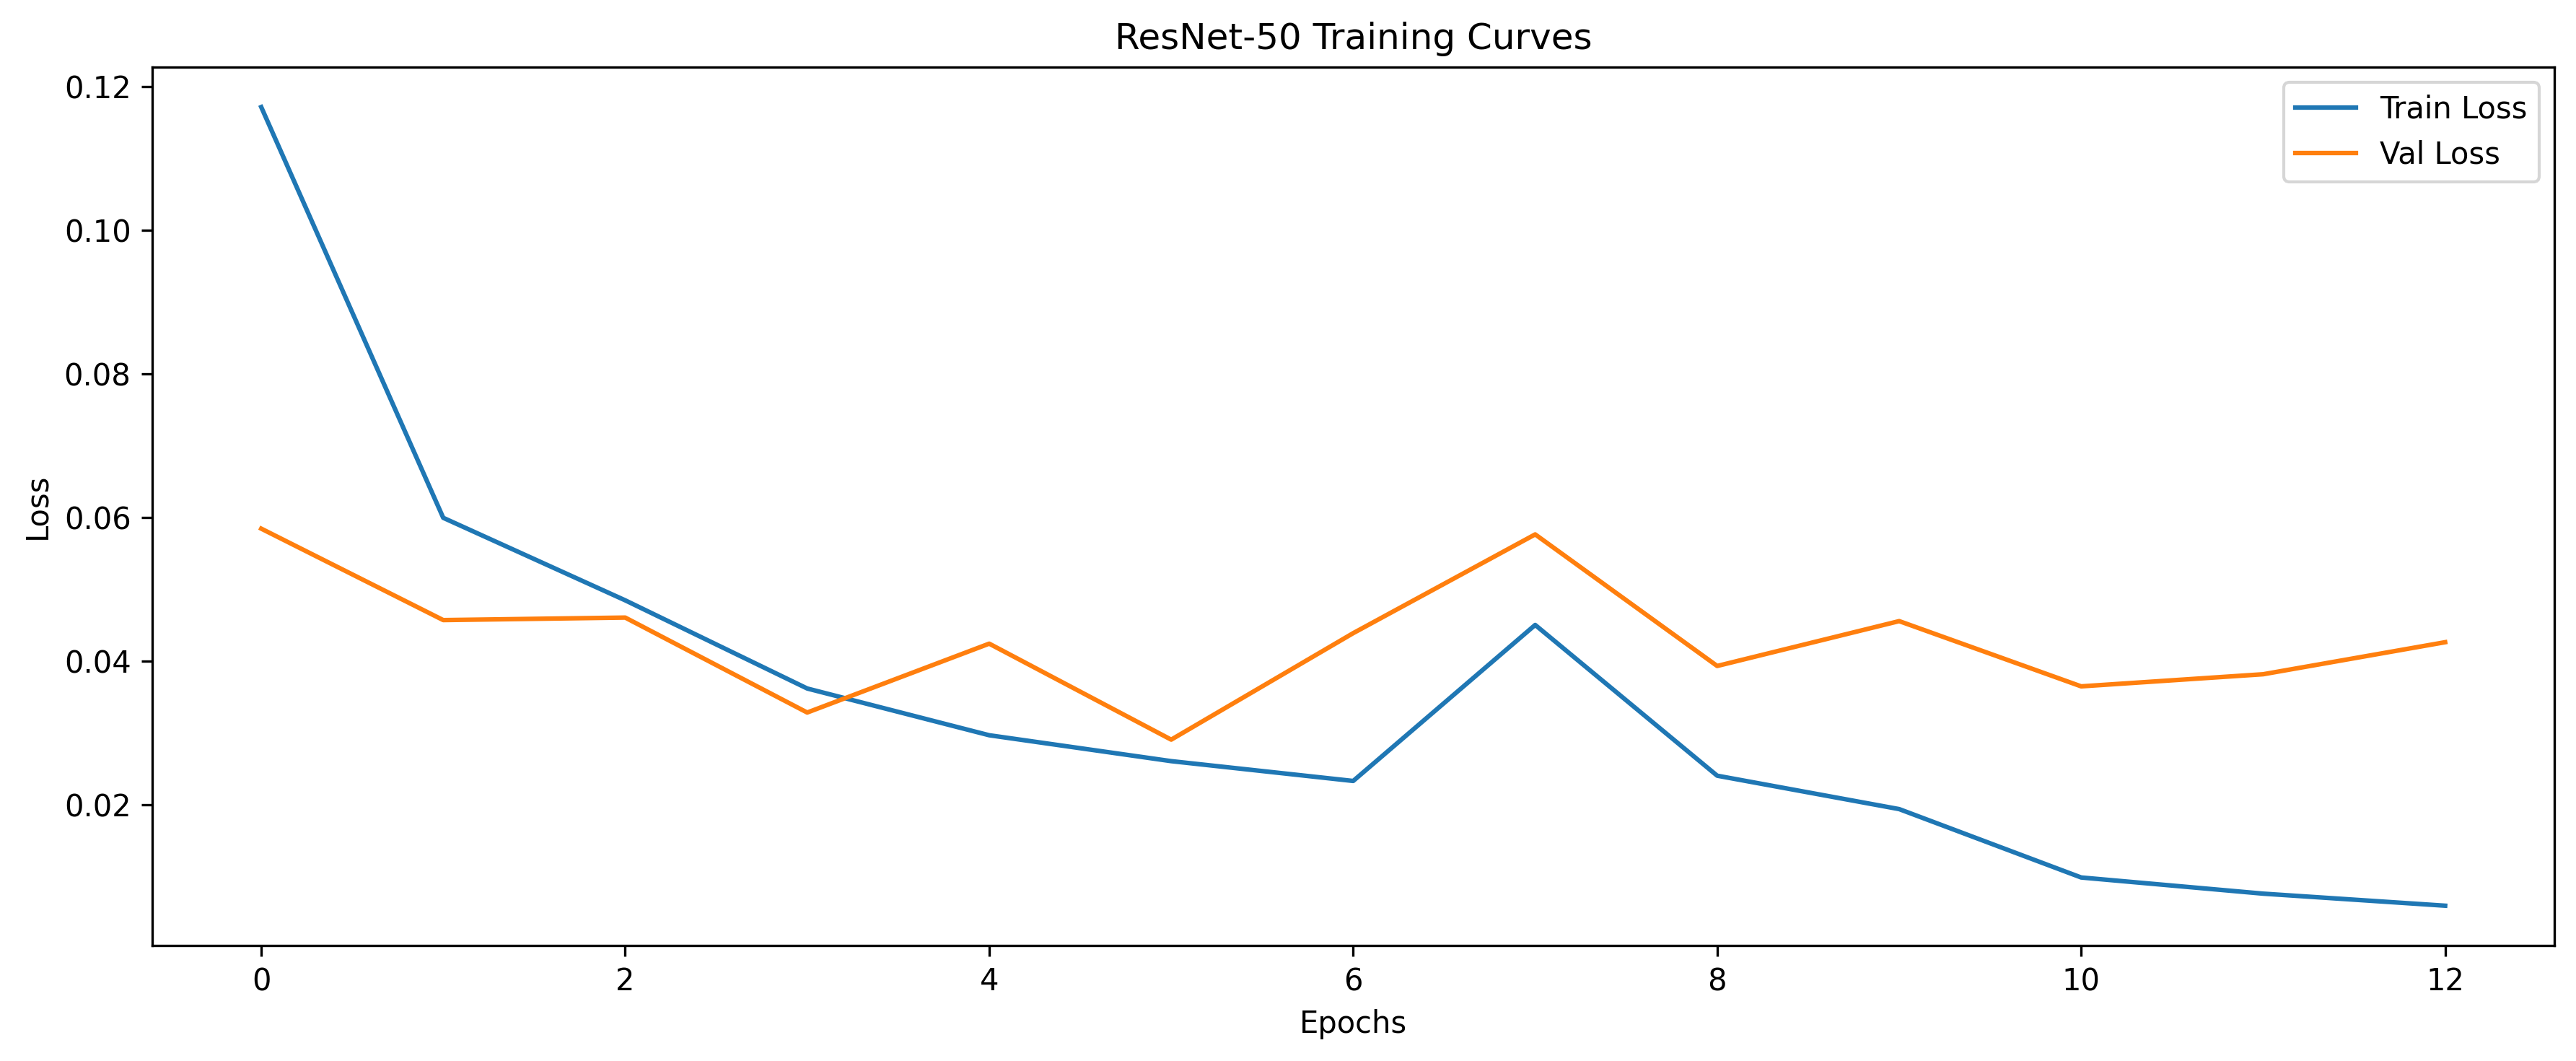

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['train_loss'], label='Train Loss')
plt.plot(history_resnet['val_loss'],   label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-50 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_resnet_50_training_curves.png'))
plt.show()

### 4.4 Free GPU Memory

In [7]:
del model_resnet
torch.cuda.empty_cache()
print("ResNet-50 removed from GPU memory.")

ResNet-50 removed from GPU memory.


---

## 5. DenseNet-121

Dense connectivity reuses feature maps from all preceding layers, making DenseNet highly
parameter-efficient. It has demonstrated strong performance in medical imaging tasks
(Rajpurkar et al., CheXNet, 2017). denseblock3 onwards is fine-tuned.

### 5.1 Initialise Model and Optimiser

In [8]:
model_densenet = get_model('densenet121').to(device)

optimiser_densenet = torch.optim.AdamW([
    {'params': model_densenet.features.denseblock3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.transition3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.norm5.parameters(),       'lr': 1e-4},
    {'params': model_densenet.classifier.parameters(),           'lr': 1e-3},
], weight_decay=1e-4)

scheduler_densenet = ReduceLROnPlateau(optimiser_densenet, mode='min', factor=0.1, patience=3)

Trainable: 5,525,249 / 6,954,881


### 5.2 Train

In [9]:
history_densenet = train(
    model        = model_densenet,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimiser    = optimiser_densenet,
    scheduler    = scheduler_densenet,
    device       = device,
    num_epochs   = 25,
    patience     = 7,
    save_path    = os.path.join(MODELS_DIR, 'densenet_121.pth')
)

Epoch 1/25 | Train Loss: 0.1040 | Val Loss: 0.0578
Epoch 2/25 | Train Loss: 0.0590 | Val Loss: 0.0407
Epoch 3/25 | Train Loss: 0.0447 | Val Loss: 0.0322
Epoch 4/25 | Train Loss: 0.0339 | Val Loss: 0.0376
Epoch 5/25 | Train Loss: 0.0251 | Val Loss: 0.0607
Epoch 6/25 | Train Loss: 0.0257 | Val Loss: 0.0453
Epoch 7/25 | Train Loss: 0.0248 | Val Loss: 0.0340
Epoch 8/25 | Train Loss: 0.0129 | Val Loss: 0.0316
Epoch 9/25 | Train Loss: 0.0146 | Val Loss: 0.0361
Epoch 10/25 | Train Loss: 0.0086 | Val Loss: 0.0327
Epoch 11/25 | Train Loss: 0.0082 | Val Loss: 0.0334
Epoch 12/25 | Train Loss: 0.0089 | Val Loss: 0.0329
Epoch 13/25 | Train Loss: 0.0084 | Val Loss: 0.0325
Epoch 14/25 | Train Loss: 0.0121 | Val Loss: 0.0364
Epoch 15/25 | Train Loss: 0.0078 | Val Loss: 0.0331
Early stopping at epoch 15


### 5.3 Plot Training Curves

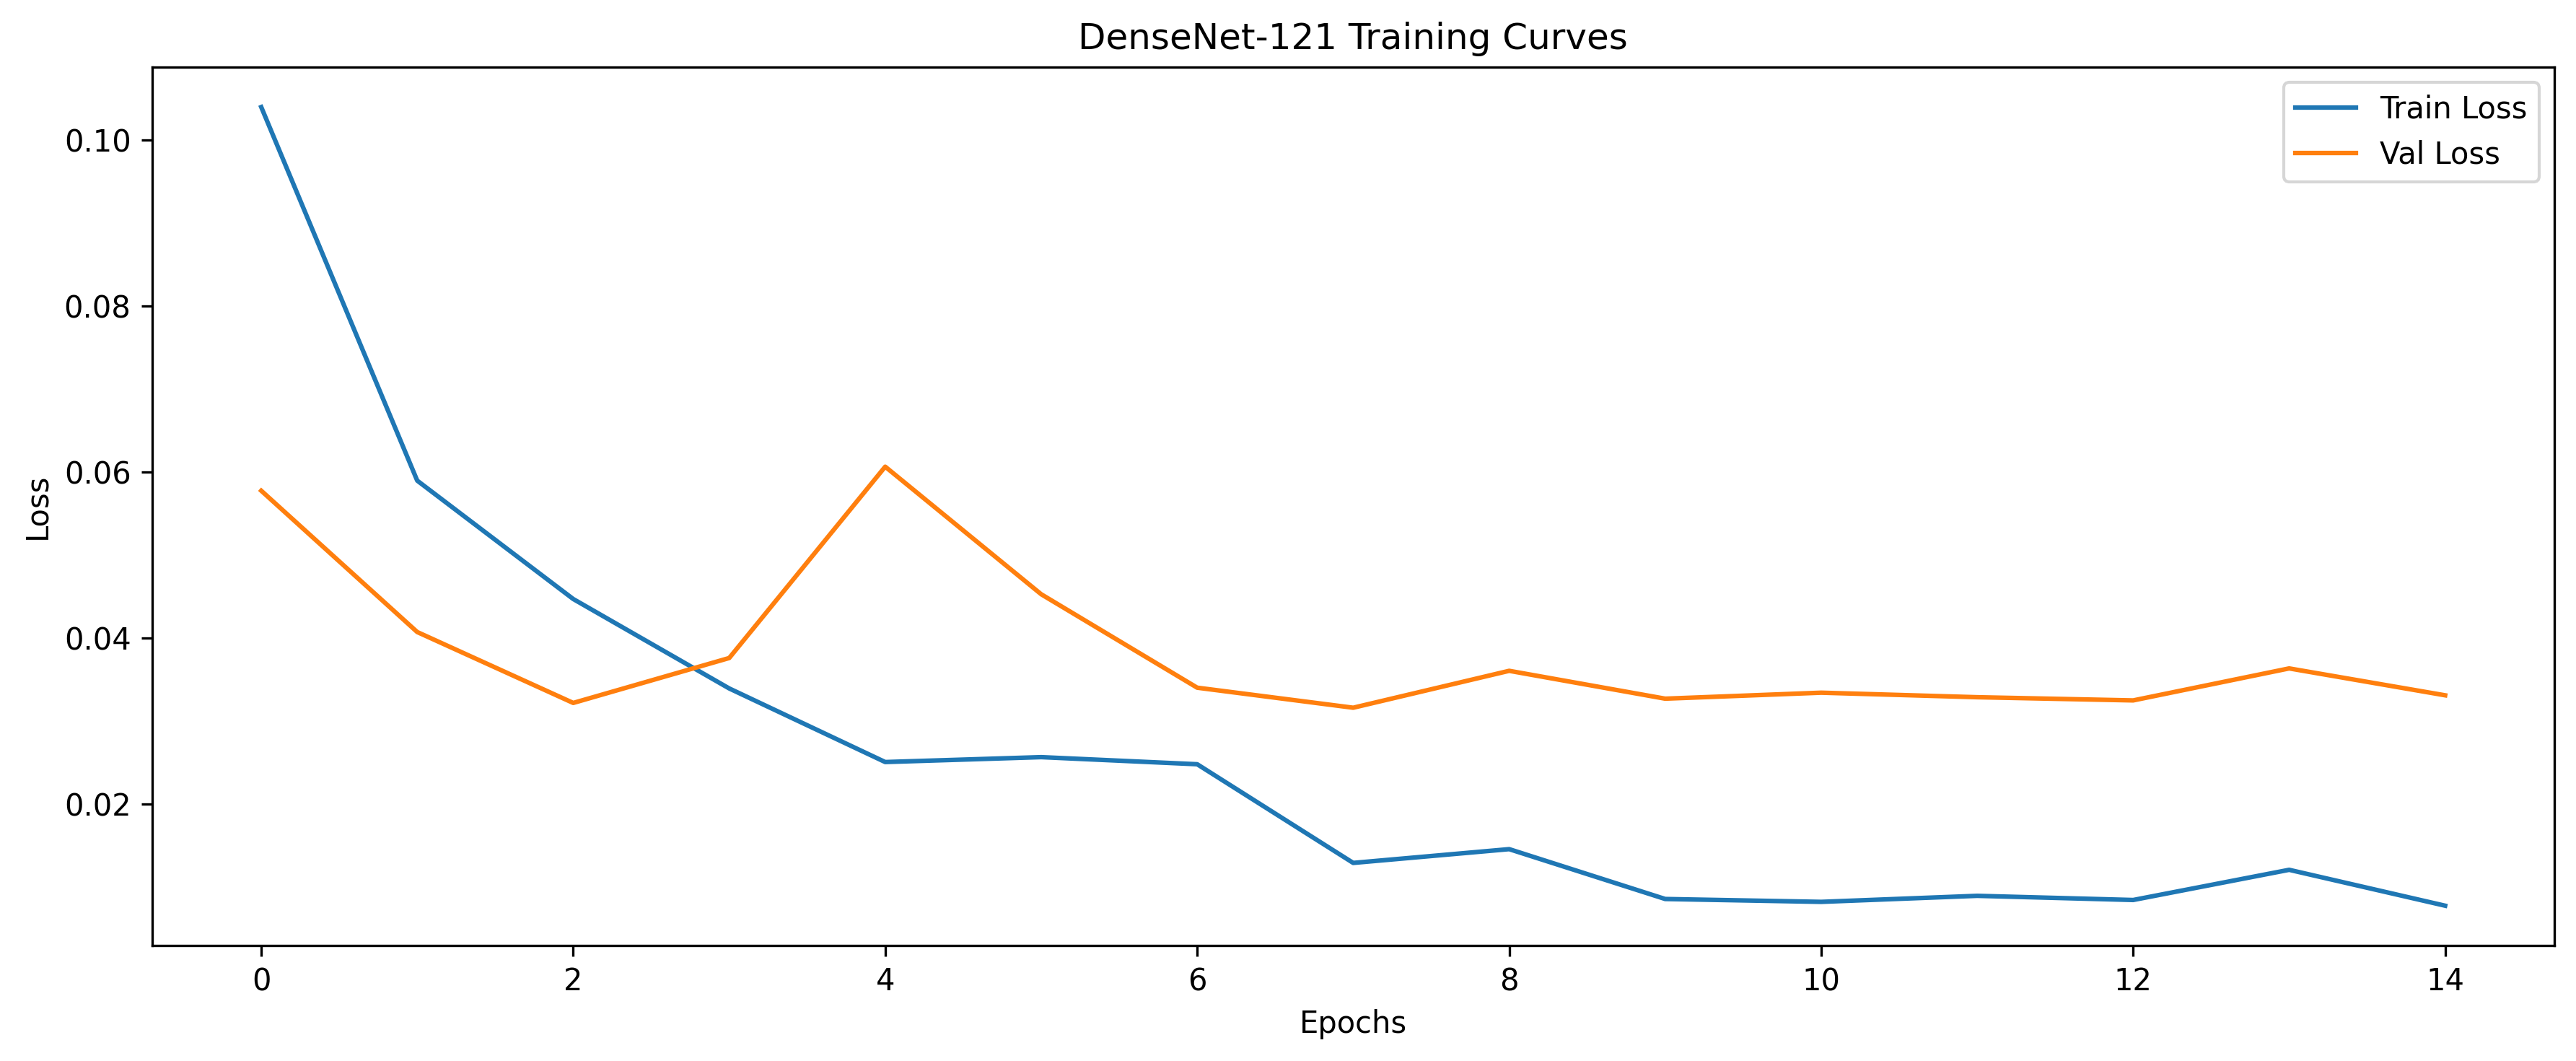

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(history_densenet['train_loss'], label='Train Loss')
plt.plot(history_densenet['val_loss'],   label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet-121 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_densenet_121_training_curves.png'))
plt.show()

### 5.4 Free GPU Memory

In [11]:
del model_densenet
torch.cuda.empty_cache()
print("DenseNet-121 removed from GPU memory.")

DenseNet-121 removed from GPU memory.


---

## 6. EfficientNet-B0

EfficientNet applies compound scaling to jointly optimise depth, width, and resolution.
It achieves competitive accuracy with fewer parameters than ResNet-50. Feature blocks
5 through 8 and the classifier are unfrozen for fine-tuning.

### 6.1 Initialise Model and Optimiser

In [12]:
model_efficientnet = get_model('efficientnet_b0').to(device)

optimiser_efficientnet = torch.optim.AdamW([
    {'params': model_efficientnet.features[5].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[6].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[7].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[8].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.classifier.parameters(),  'lr': 1e-3},
], weight_decay=1e-4)

scheduler_efficientnet = ReduceLROnPlateau(optimiser_efficientnet, mode='min', factor=0.1, patience=3)

Trainable: 3,700,169 / 4,008,829


### 6.2 Train

In [13]:
history_efficientnet = train(
    model        = model_efficientnet,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimiser    = optimiser_efficientnet,
    scheduler    = scheduler_efficientnet,
    device       = device,
    num_epochs   = 25,
    patience     = 7,
    save_path    = os.path.join(MODELS_DIR, 'efficientnet_b0.pth')
)

Epoch 1/25 | Train Loss: 0.1309 | Val Loss: 0.0864
Epoch 2/25 | Train Loss: 0.0655 | Val Loss: 0.0574
Epoch 3/25 | Train Loss: 0.0584 | Val Loss: 0.0557
Epoch 4/25 | Train Loss: 0.0487 | Val Loss: 0.0479
Epoch 5/25 | Train Loss: 0.0399 | Val Loss: 0.0507
Epoch 6/25 | Train Loss: 0.0324 | Val Loss: 0.0391
Epoch 7/25 | Train Loss: 0.0328 | Val Loss: 0.0431
Epoch 8/25 | Train Loss: 0.0277 | Val Loss: 0.0529
Epoch 9/25 | Train Loss: 0.0256 | Val Loss: 0.0330
Epoch 10/25 | Train Loss: 0.0226 | Val Loss: 0.0595
Epoch 11/25 | Train Loss: 0.0213 | Val Loss: 0.0355
Epoch 12/25 | Train Loss: 0.0174 | Val Loss: 0.0409
Epoch 13/25 | Train Loss: 0.0161 | Val Loss: 0.0553
Epoch 14/25 | Train Loss: 0.0141 | Val Loss: 0.0443
Epoch 15/25 | Train Loss: 0.0115 | Val Loss: 0.0402
Epoch 16/25 | Train Loss: 0.0086 | Val Loss: 0.0395
Early stopping at epoch 16


### 6.3 Plot Training Curves

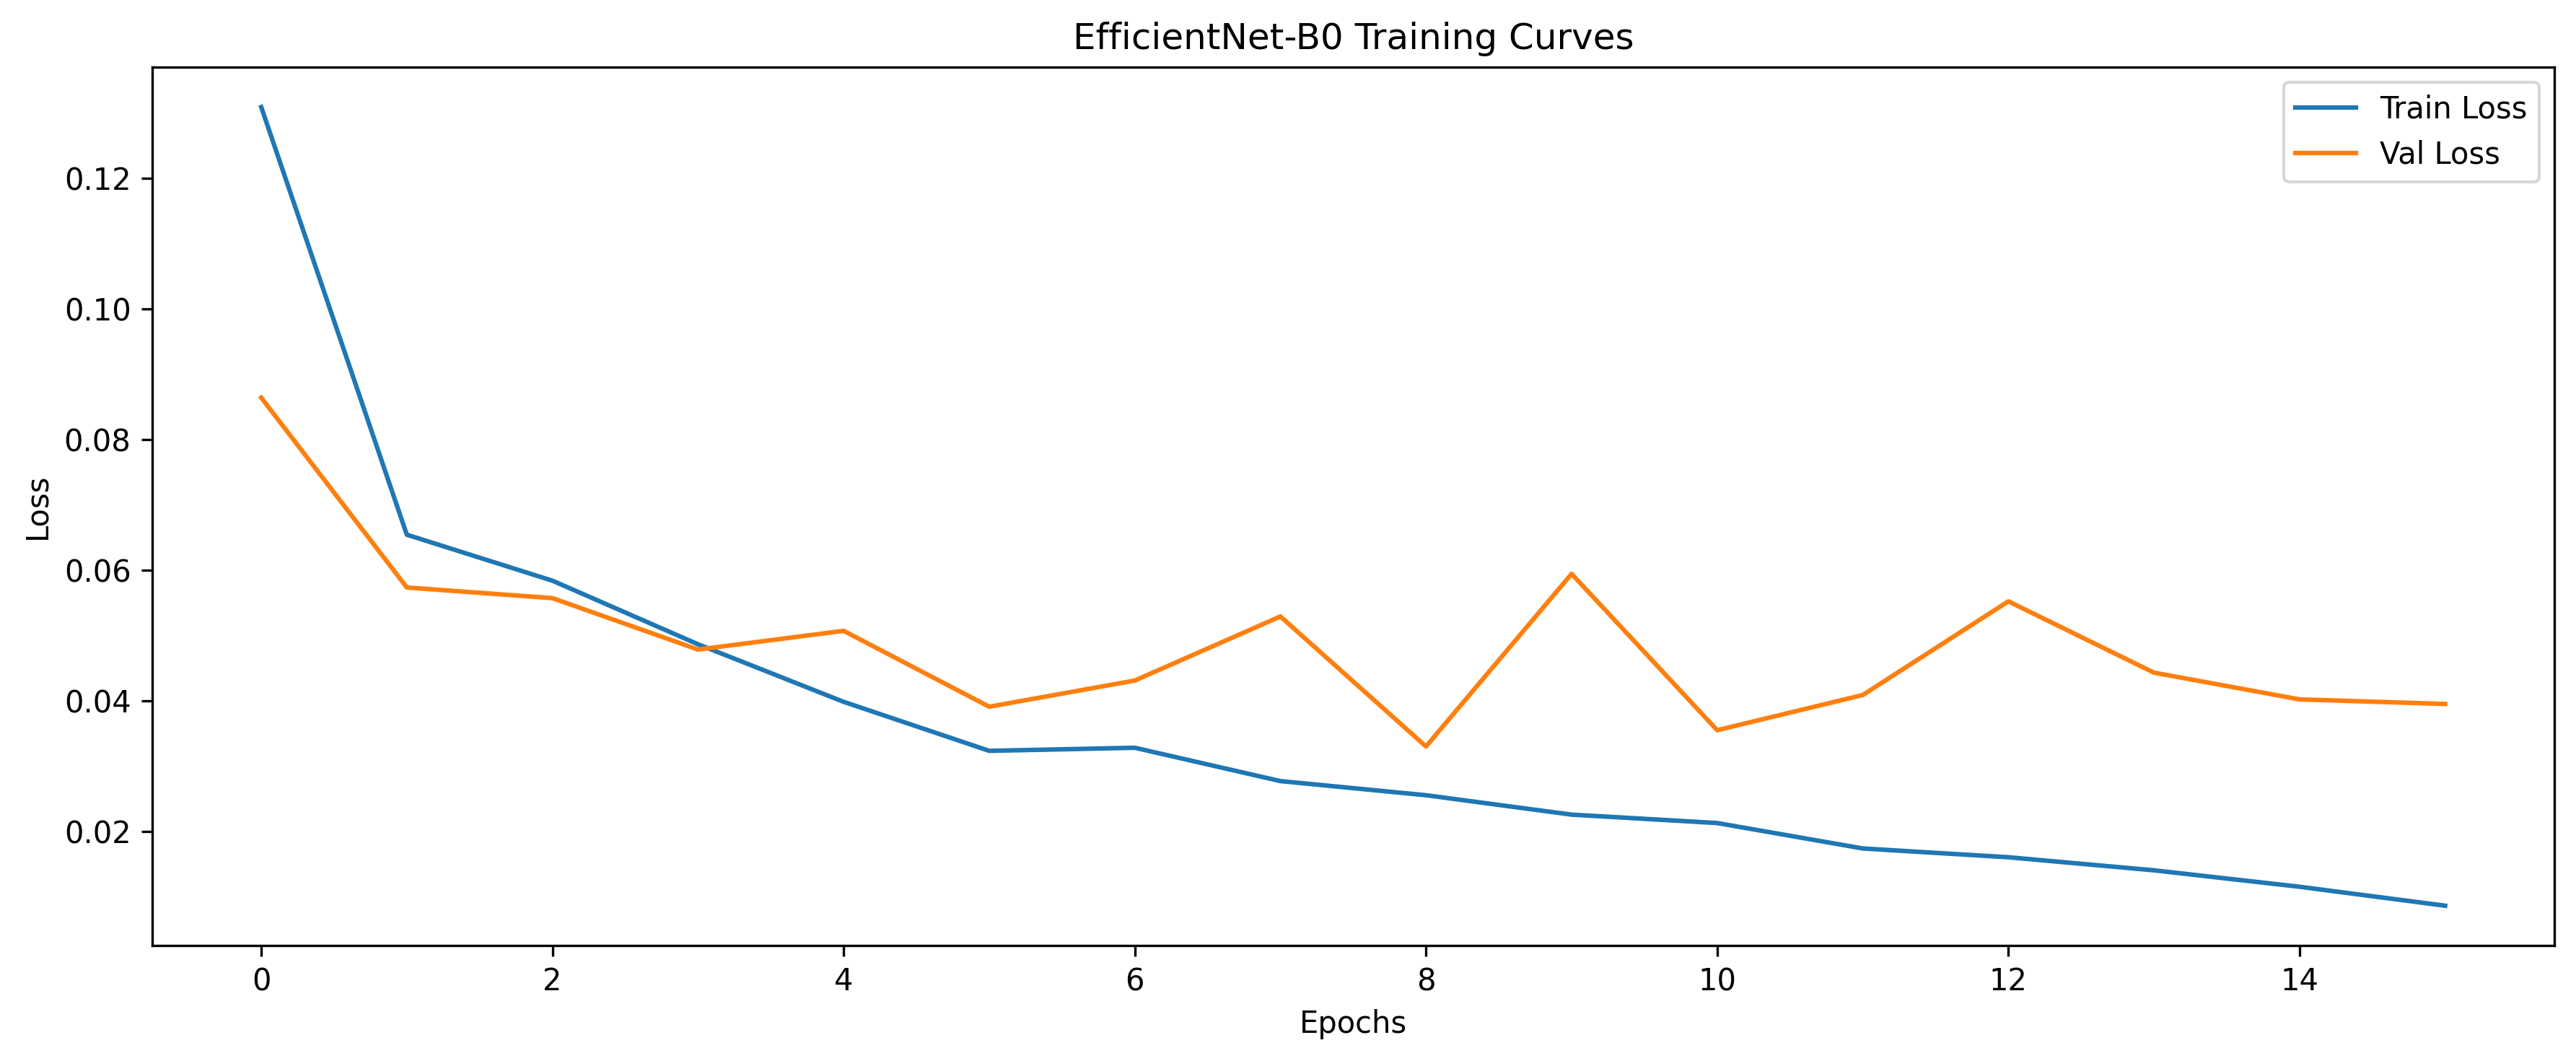

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(history_efficientnet['train_loss'], label='Train Loss')
plt.plot(history_efficientnet['val_loss'],   label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNet-B0 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_efficientnet_b0_training_curves.png'))
plt.show()

### 6.4 Free GPU Memory

In [15]:
del model_efficientnet
torch.cuda.empty_cache()
print("EfficientNet-B0 removed from GPU memory.")

EfficientNet-B0 removed from GPU memory.


---

## 7. Validation Loss Comparison

Plot all three models' validation loss curves on the same axes for direct comparison.
DenseNet-121 is expected to show the smoothest convergence.

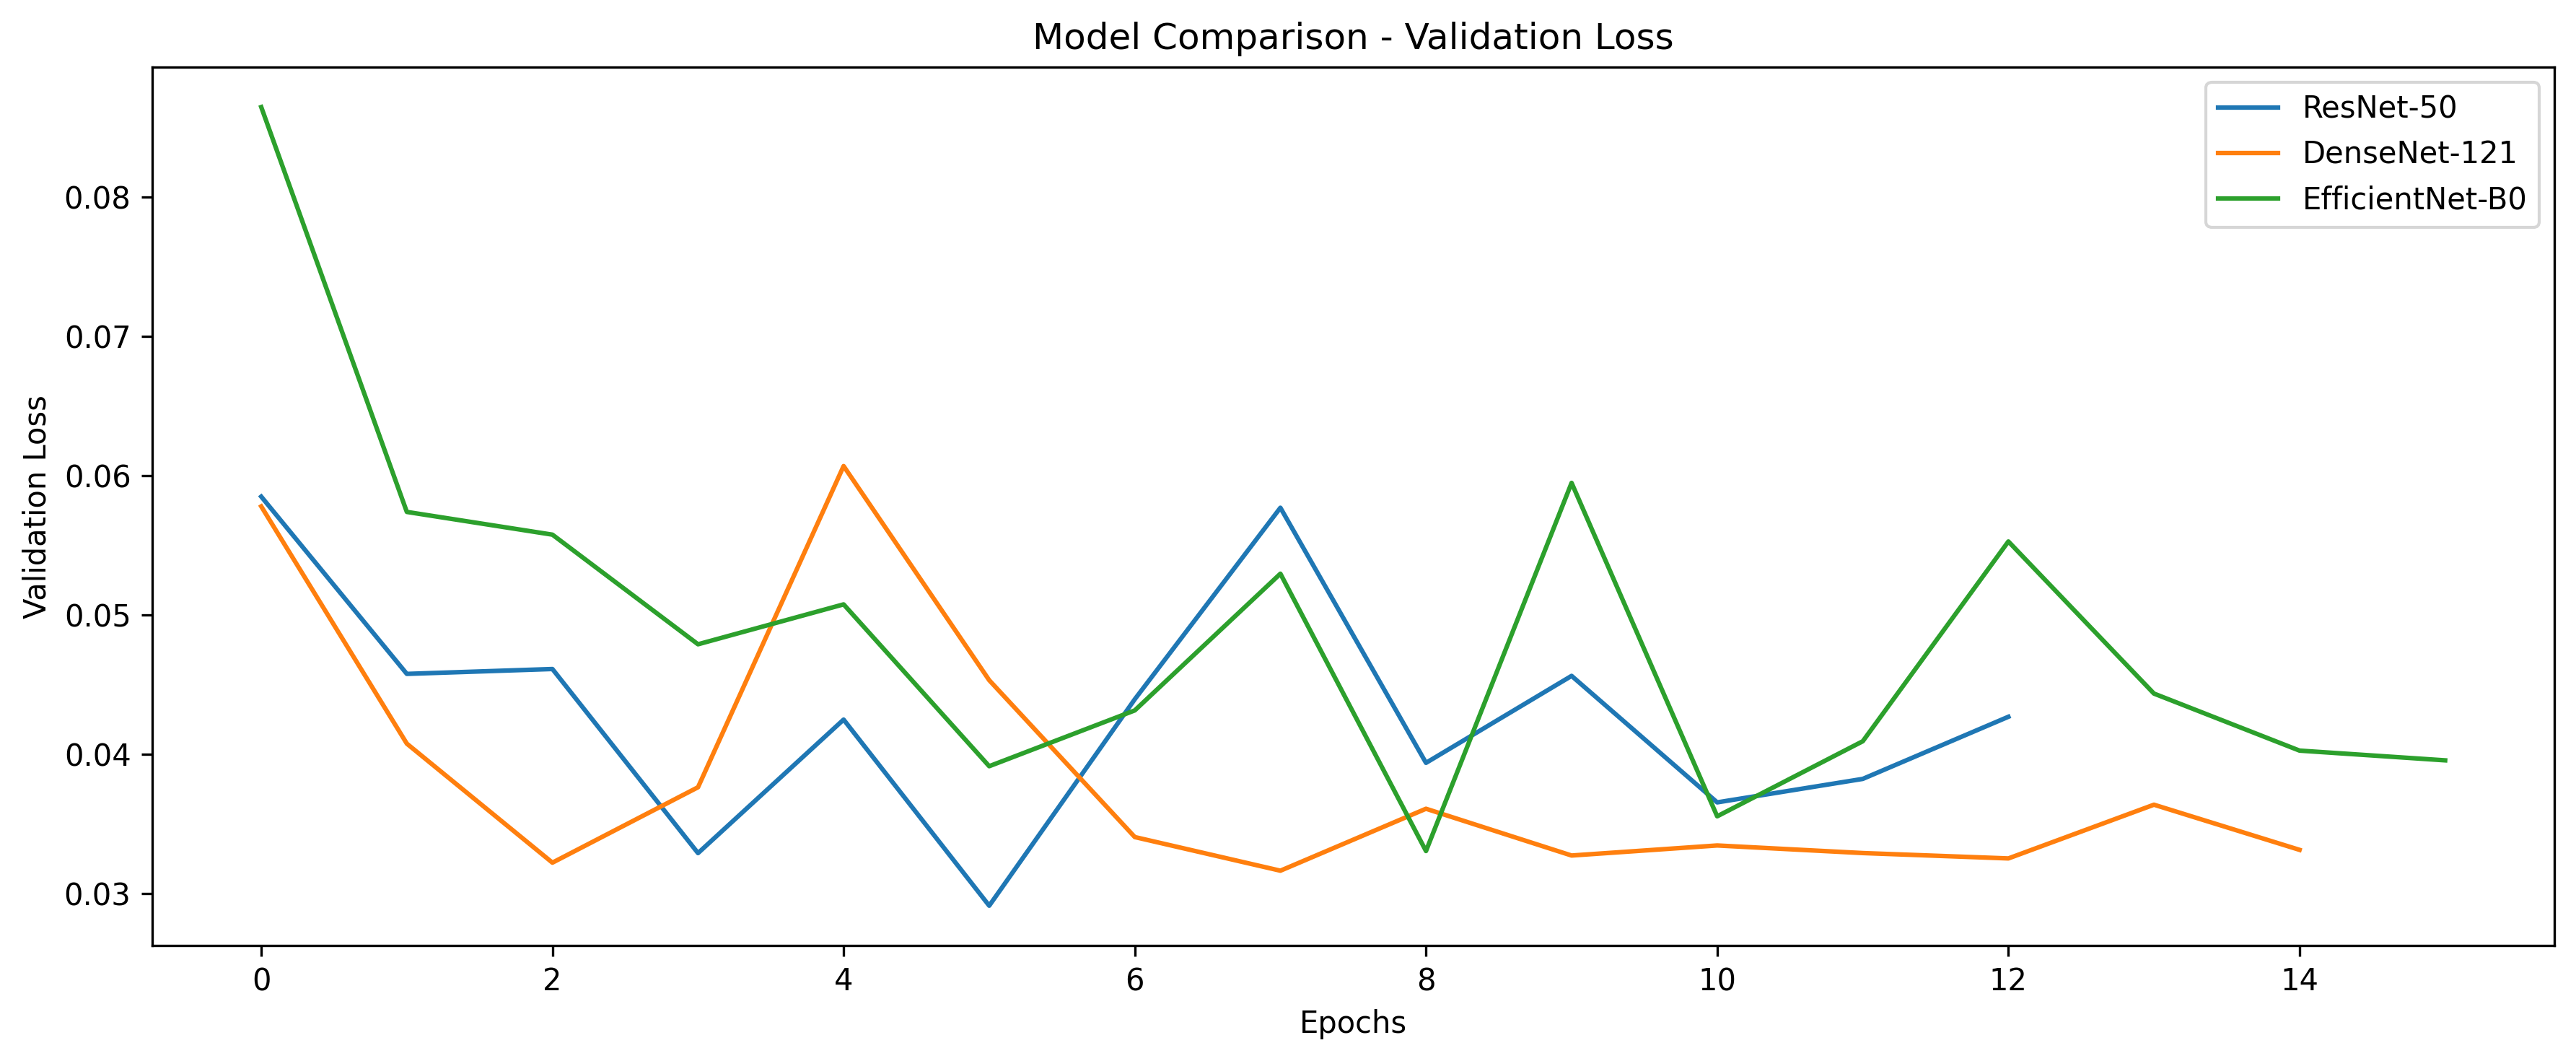

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['val_loss'],       label='ResNet-50')
plt.plot(history_densenet['val_loss'],     label='DenseNet-121')
plt.plot(history_efficientnet['val_loss'], label='EfficientNet-B0')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Model Comparison - Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig6_model_comparison.png'))
plt.show()